<a href="https://colab.research.google.com/github/Gotte-sahithi/ML-Skill/blob/main/WEEK4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [54]:
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)


In [55]:
uploaded = files.upload()

Saving Titanic-Dataset.csv to Titanic-Dataset (2).csv


In [56]:
df = pd.read_csv("Titanic-Dataset.csv")

print("Dataset:")
print(df.head())

print("\nShape of dataset:")
print(df.shape)

print("\nColumn names:")
print(df.columns)


Dataset:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN     

In [57]:
print("\nPART 1: BINARY LOGISTIC REGRESSION")
print("-" * 45)



PART 1: BINARY LOGISTIC REGRESSION
---------------------------------------------


In [58]:
# Age is the input feature
# Survived is the target

X = df[["Age"]]

y = df["Survived"]

In [59]:
# Titanic dataset contains missing Age values.
# Replace them with the median Age.

X = X.fillna(X["Age"].median())


In [60]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))



Training samples: 712
Testing samples: 179


In [61]:
binary_model = LogisticRegression()

binary_model.fit(
    X_train,
    y_train
)


LogisticRegression()

In [62]:
y_pred = binary_model.predict(
    X_test
)


In [63]:
print("\nAccuracy:")
print(
    accuracy_score(
        y_test,
        y_pred
    )
)


print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Did Not Survive",
            "Survived"
        ]
    )
)


print("\nConfusion Matrix:")

print(
    confusion_matrix(
        y_test,
        y_pred
    )
)



Accuracy:
0.5865921787709497

Classification Report:
                 precision    recall  f1-score   support

Did Not Survive       0.59      1.00      0.74       105
       Survived       0.00      0.00      0.00        74

       accuracy                           0.59       179
      macro avg       0.29      0.50      0.37       179
   weighted avg       0.34      0.59      0.43       179


Confusion Matrix:
[[105   0]
 [ 74   0]]


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [65]:
new_age = pd.DataFrame({
    "Age": [22, 45, 63]
})


predictions = binary_model.predict(
    new_age
)


print("\nPredictions:")

print(predictions)


Predictions:
[0 0 0]


In [66]:
# Probability of Survived = 1

probabilities = binary_model.predict_proba(
    new_age
)[:, 1]


print("\nPrediction Details:")


for age_val, pred, prob in zip(
    new_age["Age"],
    predictions,
    probabilities
):

    result = (
        "Survived"
        if pred == 1
        else "Did Not Survive"
    )

    print(
        f"Age {age_val}: "
        f"{result} "
        f"(Probability of Survival = {prob:.2f})"
    )



Prediction Details:
Age 22: Did Not Survive (Probability of Survival = 0.39)
Age 45: Did Not Survive (Probability of Survival = 0.35)
Age 63: Did Not Survive (Probability of Survival = 0.32)


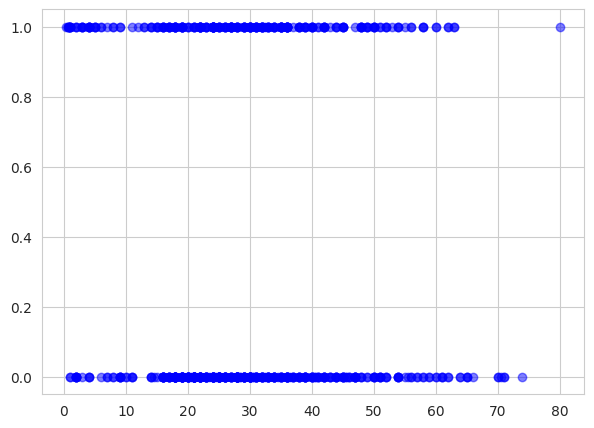

In [67]:
plt.figure(
    figsize=(7, 5)
)


# Actual Titanic data

plt.scatter(
    df["Age"],
    df["Survived"],
    color="blue",
    alpha=0.5,
    label="Actual Data"
)

In [68]:
age_range = pd.DataFrame({
    "Age": range(
        int(df["Age"].min()),
        int(df["Age"].max()) + 1
    )
})


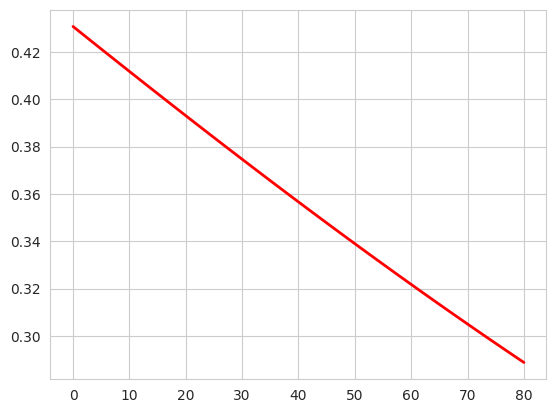

In [69]:
plt.plot(
    age_range["Age"],
    binary_model.predict_proba(
        age_range
    )[:, 1],
    color="red",
    linewidth=2,
    label="Predicted Probability"
)


/tmp/ipykernel_923/2844797232.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


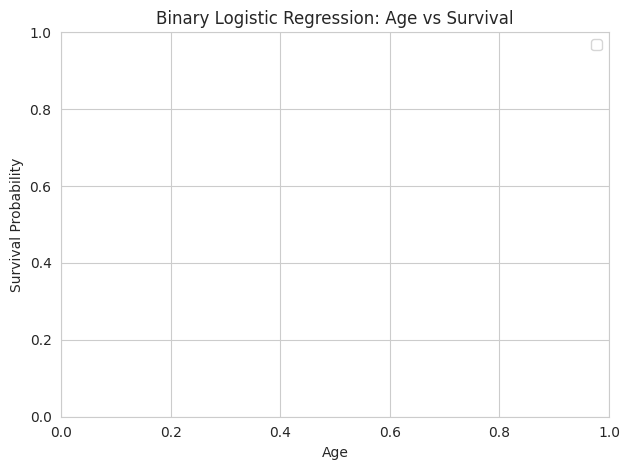

In [70]:
plt.xlabel(
    "Age"
)

plt.ylabel(
    "Survival Probability"
)

plt.title(
    "Binary Logistic Regression: Age vs Survival"
)

plt.legend()

plt.tight_layout()


In [71]:
plt.savefig(
    "titanic_binary_logistic_plot.png",
    dpi=300
)

plt.show()


print(
    "\nSaved plot -> titanic_binary_logistic_plot.png"
)

<Figure size 640x480 with 0 Axes>


Saved plot -> titanic_binary_logistic_plot.png
